In [24]:
from typing import List
from dataclasses import dataclass

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score

from dataUtils import pages_with_annotations
from transformers import AutoModel, AutoTokenizer

In [25]:
EMBEDDING_MODEL_NAME = 'Snowflake/snowflake-arctic-embed-l-v2.0'
TOKENIZER = AutoTokenizer.from_pretrained(EMBEDDING_MODEL_NAME)
EMBD_MODEL = AutoModel.from_pretrained(EMBEDDING_MODEL_NAME)

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 10008.50it/s]


In [26]:
vocab_size = TOKENIZER.get_vocab()
print(f"Tokenizer vocabulary size: {len(vocab_size)}")

Tokenizer vocabulary size: 250002


In [27]:
class NerDataset(Dataset):
    def __init__(self, data: List, tokenizer: AutoTokenizer, embedding_model: AutoModel):
        self.data = [tup for tup in data if len(tup[1]) != 0]
        self.tokenizer = tokenizer
        self.embedding_model = embedding_model
        self.sequence_length = None
    
    def __len__(self):
        return len(self.data)
    
    def get_max_length(self):
        if self.sequence_length is not None:
            return self.sequence_length
        else:
            max_len = 0
            for data_unit in self.data:
                tokenized_text = self.tokenizer(data_unit[0], return_tensors="pt")["input_ids"].flatten()
                max_len = max(max_len, len(tokenized_text))
            self.sequence_length = max_len
            return max_len
    
    def __getitem__(self, idx):
        data_unit = self.data[idx]
        entity_patterns = [data_unit[0][tup[0]: tup[1]] for tup in data_unit[1]]
        # Here we need to calculate the maximum length so that we pad everything to appropriate size
        tokenized_text = self.tokenizer(data_unit[0], padding="max_length", max_length=self.get_max_length(),
                                        truncation=True, return_tensors='pt')["input_ids"].squeeze(dim=0)
        tokenized_entities = []
        for entity_pattern in entity_patterns:
            tokenized_entity = self.tokenizer(entity_pattern, return_tensors='pt',
                                              add_special_tokens=False)["input_ids"]
            tokenized_entities.append(tokenized_entity.flatten())
        # Find and label the patterns of the sequence
        label_tensor = torch.zeros(tokenized_text.shape, dtype = torch.long)
        for entity in tokenized_entities:
            unfolded_text = tokenized_text.unfold(0, len(entity), 1)
            row_matches = (unfolded_text == entity).all(dim = 1)
            start_ind = torch.nonzero(row_matches, as_tuple = True)[0]
            if len(start_ind):
                unfolded_text = tokenized_text.unfold(0, len(entity)-1, 1)
                row_matches = (unfolded_text == entity[1:]).all(dim = 1)
                start_ind = torch.nonzero(row_matches, as_tuple = True)[0] - 1
            label_tensor[start_ind] = torch.tensor(2, dtype=torch.long)
            for forward_ind in range(1, len(entity)):
                label_tensor[start_ind + forward_ind] = 1
        return tokenized_text, label_tensor

In [28]:
# Different types of RNNs, biRNNs, and multi-layered RNNs 
class NERModel(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int,
                 embedding_model: AutoTokenizer, num_layers: int = 2, num_tags: int = 3):
        super().__init__()
        self.embedding_model = embedding_model
        self.classifier = nn.Linear(hidden_dim, num_tags)
        self.rnn = nn.RNN(input_size=input_dim, hidden_size=hidden_dim, num_layers=num_layers)

    def forward(self, x: torch.tensor) -> torch.tensor:
        """x is tensor of shape BxS where B is batch size and S is sequence length of inputs"""
        with torch.no_grad():
            emb_x = self.embedding_model(x).last_hidden_state
        emb_x = torch.permute(emb_x, (1, 0, 2)) 
        out, _ = self.rnn(emb_x)
        out = torch.permute(out, (1, 0, 2))
        y = self.classifier(out) # B x S x E
        return y

In [29]:
def train_epoch(model: nn.Module, dataloader: DataLoader, optimizer: optim.Optimizer,
                criterion: nn.Module, device: torch.device, num_tags: int = 3) -> float:
    model.train()
    total_loss = 0.0
    for seqs, tags in tqdm(dataloader, desc='Going through loader ...'):
        seqs, tags = seqs.to(device), tags.to(device)
        optimizer.zero_grad()
        logits = model(seqs).view(-1, num_tags) # B x S x T
        loss = criterion(logits, tags.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    average_loss = total_loss / len(dataloader)
    return average_loss

def validate(model: nn.Module, dataloader: DataLoader,
             device: torch.device = "cuda") -> float:
    model.eval()
    y_pred = []
    y_true = []
    for seq, tags in tqdm(dataloader, desc='Going through validation loader ..'):
        seq, tags = seq.to(device=device), tags.to(device=device)
        y_batch_pred = model(seq).softmax(dim=-1).argmax(dim=-1).view(-1).detach().cpu().numpy()
        y_batch_true = tags.view(-1).detach().cpu().numpy()
        y_pred.append(y_batch_pred)
        y_true.append(y_batch_true)
    return f1_score(y_pred=np.hstack(y_pred), y_true=np.hstack(y_true), average="macro")

In [30]:
def train_model(model: nn.Module, train_loader: DataLoader,
                val_loader: DataLoader, optimizer: optim.Optimizer, criterion: nn.Module, 
                epochs: int, device: torch.device, save_path: str, name: str):
    try:
        all_avg_losses = []
        all_val_scores = []
        for epoch in range(epochs):
            average_train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
            validation_score = validate(model, val_loader, device)
            all_avg_losses.append(average_train_loss)
            all_val_scores.append(validation_score)
            print(f"Epoch {epoch+1} | Train Loss: {average_train_loss:.4f} | Val f1-score: {validation_score}")
            torch.save(model.rnn.state_dict(), f = save_path + f"\\{name}_epoch#{epoch}.pth")
        return all_avg_losses, all_val_scores
    except KeyboardInterrupt:
        return all_avg_losses, all_val_scores

In [31]:
@dataclass(frozen=True)
class TrainConfig:
    BATCH_SIZE: int = 6
    LR: float = 0.001
    BETAS = (0.9, 0.98)

In [32]:
train_config = TrainConfig()

In [33]:
ner_model = NERModel(input_dim = 1024, hidden_dim = 256, 
                     num_layers = 2, embedding_model = EMBD_MODEL).to(device='cuda')

In [34]:
# Load datasets
train_annotated = pages_with_annotations(folder_path = ".\\TrainData")
train_dataset = NerDataset(train_annotated, TOKENIZER, EMBD_MODEL)

test_annotated = pages_with_annotations(folder_path = ".\\TestData")
test_dataset = NerDataset(test_annotated, TOKENIZER, EMBD_MODEL)

print(f"Length of train dataset: {len(train_dataset)}")
print(f"Length of test dataset: {len(test_dataset)}")

Going through pdf documents: 100%|██████████| 1/1 [00:00<00:00,  6.57it/s]

Length of train dataset: 27
Length of test dataset: 12


In [35]:
# Prepare loaders
train_loader = DataLoader(dataset = train_dataset, batch_size = train_config.BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset = test_dataset, batch_size = train_config.BATCH_SIZE, shuffle=True)

In [36]:
import torch.nn as nn

def count_parameters(model: nn.Module) -> int:
    """Return total number of trainable parameters in model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [37]:
count_parameters(ner_model.rnn)

459776

### Elman RNN (num_layers = 2, hidden_size = 256)

In [38]:
@dataclass(frozen=True)
class TrainConfig:
    BATCH_SIZE: int = 6
    LR: float = 0.001
    BETAS = (0.9, 0.98)
train_config = TrainConfig()

In [39]:
ner_model = NERModel(input_dim = 1024, hidden_dim = 256, 
                     num_layers = 2, embedding_model = EMBD_MODEL).to(device='cuda')

In [40]:
optimizer = torch.optim.Adam(ner_model.parameters(), lr=train_config.LR, betas=train_config.BETAS)
criterion = nn.CrossEntropyLoss()

In [ ]:
result = train_model(model = ner_model,
            train_loader = train_loader,
            val_loader = test_loader,
            optimizer = optimizer,
            criterion = criterion,
            epochs = 100,
            device = "cuda",
            save_path="C:\\main\\GitHub\\documentReviewSystem\\NERTraining\\models",
            name="ELMAN_RNN_LAYERS_2_HIDDEN_256"
            )

Going through validation loader ..: 100%|██████████| 2/2 [01:03<00:00, 31.93s/it]


Epoch 1 | Train Loss: 1.0286 | Val f1-score: 0.06379583156296753


Going through validation loader ..: 100%|██████████| 2/2 [01:04<00:00, 32.12s/it]


Epoch 2 | Train Loss: 0.8603 | Val f1-score: 0.36671127377720536


Going through validation loader ..: 100%|██████████| 2/2 [01:04<00:00, 32.07s/it]


...

Going through validation loader ..: 100%|██████████| 2/2 [01:03<00:00, 31.73s/it]


Epoch 14 | Train Loss: 0.2836 | Val f1-score: 0.5520804770220046


Going through validation loader ..: 100%|██████████| 2/2 [01:03<00:00, 31.94s/it]


Epoch 15 | Train Loss: 0.2172 | Val f1-score: 0.557953873416548


Going through loader ...:  60%|██████    | 3/5 [03:16<02:10, 65.42s/it]

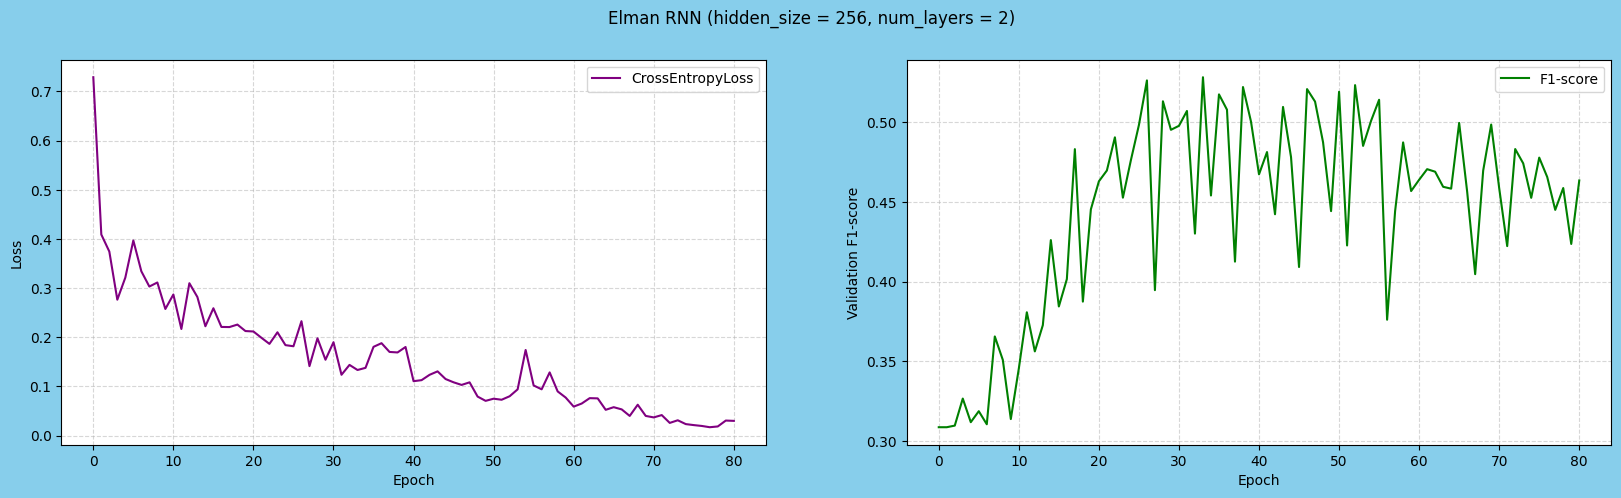

In [ ]:
graph_figure = plt.figure(figsize=(20, 5), facecolor='skyblue')
graph_figure.suptitle("Elman RNN (hidden_size = 256, num_layers = 2)")
graph_ax1 = graph_figure.add_subplot(1, 2, 1)
graph_ax2 = graph_figure.add_subplot(1, 2, 2)
graph_ax1.grid(linestyle='--', alpha=0.5)
graph_ax1.set_xlabel("Epoch")
graph_ax1.set_ylabel("Loss")
graph_ax1.plot(result[0], label = 'CrossEntropyLoss', color='purple')
graph_ax1.legend()
graph_ax2.grid(linestyle='--', alpha=0.5)
graph_ax2.set_xlabel("Epoch")
graph_ax2.set_ylabel("Validation F1-score")
graph_ax2.plot(result[1], label = 'F1-score', color='green')
graph_ax2.legend()

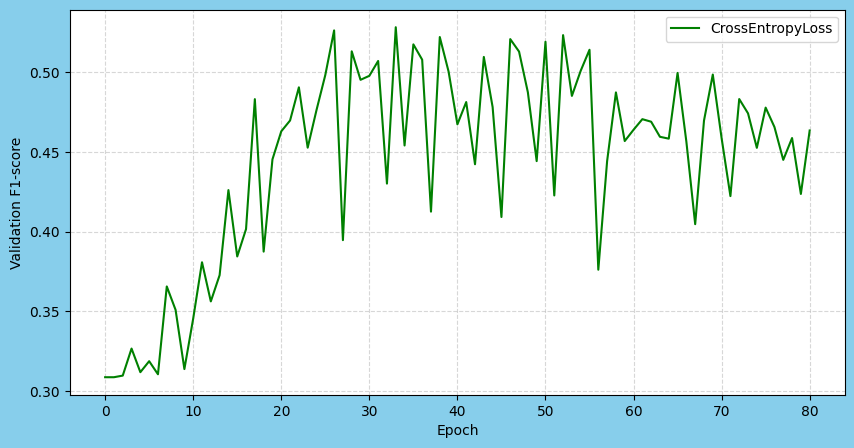

In [ ]:
graph_figure = plt.figure(figsize=(10, 5), facecolor='skyblue')
graph_ax = graph_figure.add_subplot()
graph_ax.grid(linestyle='--', alpha=0.5)
graph_ax.set_xlabel("Epoch")
graph_ax.set_ylabel("Validation F1-score")
graph_ax.plot(result[1], label = 'CrossEntropyLoss', color='green')
graph_ax.legend()